In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
# Step 1 — Check your columns first
print(df.columns.tolist())
print(df.shape)

['age', 'gender', 'country', 'education', 'marital_status', 'income_level', 'employment_status', 'work_hours_per_week', 'remote_work', 'job_satisfaction', 'work_stress_level', 'work_life_balance', 'ever_bullied_at_work', 'company_mental_health_support', 'exercise_per_week', 'sleep_hours_night', 'caffeine_drinks_day', 'alcohol_frequency', 'smoking', 'screen_time_hours_day', 'social_media_hours_day', 'hobby_time_hours_week', 'diet_quality', 'financial_stress', 'feeling_sad_down', 'loss_of_interest', 'sleep_trouble', 'fatigue', 'poor_appetite_or_overeating', 'feeling_worthless', 'concentration_difficulty', 'anxious_nervous', 'panic_attacks', 'mood_swings', 'irritability', 'obsessive_thoughts', 'compulsive_behavior', 'self_harm_thoughts', 'suicidal_thoughts', 'family_history_mental_illness', 'previously_diagnosed', 'ever_sought_treatment', 'on_therapy_now', 'on_medication', 'trauma_history', 'social_support', 'close_friends_count', 'feel_understood', 'loneliness', 'discuss_mental_health', 

In [14]:
# Step 2 — Always reload from the original file before modeling
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# Step 3 — Preprocess WITHOUT losing the target
from sklearn.preprocessing import LabelEncoder

# Encode categoricals (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Step 4 — Now safely split
X = df.drop("Has_Mental_Health_Issue", axis=1)
y = df["Has_Mental_Health_Issue"]

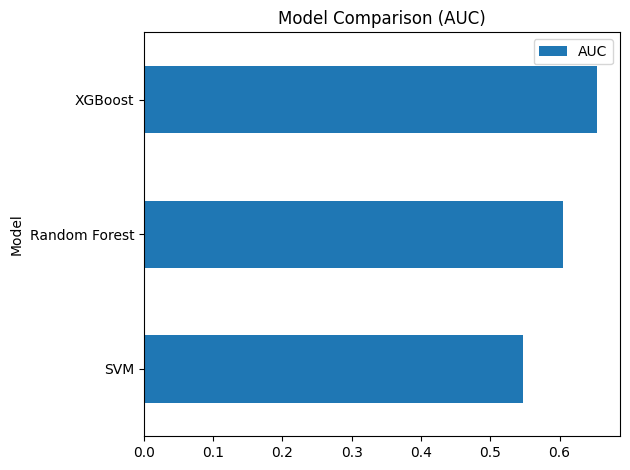

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Define features and target
X = df.drop("Has_Mental_Health_Issue", axis=1)
y = df["Has_Mental_Health_Issue"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define models
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results.append([name, auc])

# Save results
df_auc = pd.DataFrame(results, columns=["Model", "AUC"])
df_auc.to_csv("RQ2_table.csv", index=False)

# Plot
df_auc.sort_values("AUC").plot(kind='barh', x='Model', y='AUC')
plt.title("Model Comparison (AUC)")
plt.tight_layout()
plt.savefig("RQ2_figure.pdf")
plt.show()